# GridSearchCV - Podešavanje hiperparametara

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import neighbors
from sklearn import model_selection as skms
from sklearn import datasets
iris = datasets.load_iris()
diabetes = datasets.load_diabetes()
digits = datasets.load_digits()

In [2]:
knn = neighbors.KNeighborsClassifier()
print(" ".join(knn.get_params().keys()))

algorithm leaf_size metric metric_params n_jobs n_neighbors p weights


In [3]:
param_grid = {
    "n_neighbors": [1, 3, 5, 10, 20]}

knn = neighbors.KNeighborsClassifier()
grid_model = skms.GridSearchCV(knn, return_train_score=True, param_grid = param_grid, cv=10)
grid_model.fit(digits.data, digits.target)
print(grid_model)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 10, 20]},
             return_train_score=True)


In [5]:
param_cols= ["param_n_neighbors"]
score_cols = ["mean_train_score", "std_train_score", "mean_test_score", "std_test_score"]

df = pd.DataFrame(grid_model.cv_results_).head()
display(df[param_cols + score_cols])

,param_n_neighbors,mean_train_score,std_train_score,mean_test_score,std_test_score
0,1,1.000000,0.000000,0.974963,0.017080
1,3,0.993322,0.000772,0.976633,0.015473
2,5,0.990540,0.000621,0.971074,0.017169
3,10,0.985655,0.001291,0.962163,0.020458
4,20,0.980832,0.001933,0.958824,0.022388


In [6]:
grid_df = pd.DataFrame(grid_model.cv_results_, columns=["param_n_neighbors", "mean_train_score", "mean_test_score"])
grid_df.set_index("param_n_neighbors", inplace=True)
display(grid_df)

,mean_train_score,mean_test_score
param_n_neighbors,,
1,1.000000,0.974963
3,0.993322,0.976633
5,0.990540,0.971074
10,0.985655,0.962163
20,0.980832,0.958824


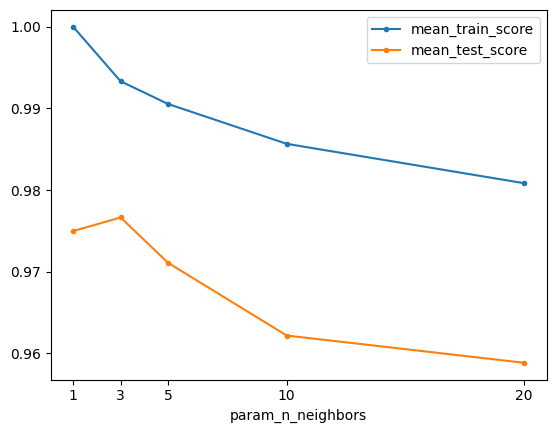

In [7]:
ax = grid_df.plot.line(marker = '.')
ax.set_xticks(grid_df.index)

In [8]:
param_grid = {
    "n_neighbors": np.arange(1, 11),
    "weights": ["uniform", "distance"],
    "p": [1, 2, 4, 8, 16]
    } # 1000 puta će testirati model s zadanim hiperparaterima

knn = neighbors.KNeighborsClassifier()
grid_model = skms.GridSearchCV(knn, param_grid = param_grid, cv=10)
%timeit -r1 grid_model.fit(iris.data, iris.target)



3.67 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [9]:
param_df = pd.DataFrame.from_records(grid_model.cv_results_['params'])
param_df['mean_test_score'] = grid_model.cv_results_['mean_test_score']
param_df.sort_values(by=['mean_test_score']).tail()

,n_neighbors,p,weights,mean_test_score
95,10,4,distance,0.98
96,10,8,uniform,0.98
97,10,8,distance,0.98
98,10,16,uniform,0.98
99,10,16,distance,0.98


In [17]:
print("Best Estimator: " , grid_model.best_estimator_, "\n-----------------------",
"Best Score: " , grid_model.best_score_, "\n-----------------------",
"Best Params: " , grid_model.best_params_, sep="\n")

Best Estimator: 
KNeighborsClassifier(n_neighbors=np.int64(8), p=4)

-----------------------
Best Score: 
0.9800000000000001

-----------------------
Best Params: 
{'n_neighbors': np.int64(8), 'p': 4, 'weights': 'uniform'}


#RandomizedSearchCV - ne testira sve, nego nasumično uzima određeni broj uzoraka i na osnovu toga vraća rezultat

In [19]:
import scipy.stats as ss

In [22]:
knn = neighbors.KNeighborsClassifier()
param_dists = {"n_neighbors" : ss.randint(1,11),
               "weights"     : ['uniform', 'distance'],
               "p"           : ss.geom(p=.5)}

mod = skms.RandomizedSearchCV(knn,
                              param_distributions = param_dists,
                              cv=10,
                              n_iter=20)# sample 20x

%timeit -r1 mod.fit(iris.data, iris.target)
print(mod.best_score_)

580 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
0.9800000000000001


#Ugnježdeni CV

In [24]:
param_grid = {
    "n_neighbors": np.arange(1, 11),
    "weights": ["uniform", "distance"],
    "p": [1, 2, 4, 8, 16]
    }

knn = neighbors.KNeighborsClassifier()
grid_knn = skms.GridSearchCV(knn, param_grid = param_grid, cv=3) ## GridSearchCV
print(grid_knn)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'p': [1, 2, 4, 8, 16],
                         'weights': ['uniform', 'distance']})


In [25]:
outer_scores = skms.cross_val_score(grid_knn, iris.data, iris.target, cv=5)
print(outer_scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [26]:
grid_knn.fit(iris.data, iris.target)
preferred_params = grid_knn.best_estimator_.get_params()
final_knn = neighbors.KNeighborsClassifier(**preferred_params) ## običan knn model
final_knn.fit(iris.data, iris.target)

KNeighborsClassifier(n_neighbors=np.int64(4))

# Gist - primjer koji je dao ChatGTP

In [27]:
# Nested CV primjer na Adult (income) skupu podataka
# - Unutarnja CV: GridSearchCV (tuning hiperparametara)
# - Vanjska CV: StratifiedKFold (nepristrana procjena nakon tuninga)

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1) Učitaj Adult (preko scikit-learn-a)
adult = fetch_openml("adult", version=2, as_frame=True)
X = adult.data
y = adult.target

# Target je string ('<=50K', '>50K'); pretvorimo u 0/1
y = (y == ">50K").astype(int)

# 2) Podjela kolona po tipu
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# 3) Pretprocesiranje:
#    - numeričke: imputacija medianom + skaliranje
#    - kategorijske: imputacija najčešćom + OneHotEncoder (drop='first' + handle_unknown)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# 4) Cijeli pipeline: preprocesor + klasifikator
pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        solver="liblinear",            # stabilno za binarni problem
        max_iter=1000
    ))
])

# 5) Grid za tuning unutar unutarnje CV
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

# 6) Unutarnja i vanjska CV
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)   # za GridSearchCV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # za nested evaluaciju

# 7) GridSearchCV (unutarnja CV)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)

# 8) Brza nested evaluacija: cross_val_score nad GridSearchCV (vanjska CV)
outer_scores = cross_val_score(gs, X, y, cv=outer_cv, scoring="roc_auc", n_jobs=-1)
print(f"Nested CV AUC: {outer_scores.mean():.4f} +/- {outer_scores.std():.4f}")

# 9) (Opcionalno) Ručni prikaz po vanjskom foldu – da se vidi da se tuning radi na trainu, a test je netaknut
#    Ovo ispisuje best parametre po foldu i AUC na vanjskom testu.
print("\nDetalji po vanjskom foldu:")
fold_aucs = []
for i, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    # Fit unutarnjeg GridSearch-a SAMO na vanjskom trainu
    gs.fit(X_tr, y_tr)

    # Predikcija na vanjskom testu (tek sada ga "vidimo")
    y_proba = gs.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_proba)
    fold_aucs.append(auc)

    print(f"Fold {i}: best_params={gs.best_params_}, inner_CV_AUC={gs.best_score_:.4f}, outer_test_AUC={auc:.4f}")

print(f"\nProsječni outer AUC (ručno): {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}")

Nested CV AUC: 0.9051 +/- 0.0021

Detalji po vanjskom foldu:
Fold 1: best_params={'clf__C': 1, 'clf__class_weight': None}, inner_CV_AUC=0.9059, outer_test_AUC=0.9028


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 2: best_params={'clf__C': 1, 'clf__class_weight': 'balanced'}, inner_CV_AUC=0.9050, outer_test_AUC=0.9062
Fold 3: best_params={'clf__C': 1, 'clf__class_weight': 'balanced'}, inner_CV_AUC=0.9058, outer_test_AUC=0.9025
Fold 4: best_params={'clf__C': 0.1, 'clf__class_weight': None}, inner_CV_AUC=0.9046, outer_test_AUC=0.9078
Fold 5: best_params={'clf__C': 1, 'clf__class_weight': 'balanced'}, inner_CV_AUC=0.9050, outer_test_AUC=0.9060

Prosječni outer AUC (ručno): 0.9051 +/- 0.0021


# Pipelines

In [31]:
from sklearn import pipeline
from sklearn import preprocessing as skpre
from sklearn import linear_model
from sklearn import model_selection as skms

In [33]:
scaler = skpre.StandardScaler()
logreg = linear_model.LogisticRegression()

pipe = pipeline.make_pipeline(scaler, logreg)
print(skms.cross_val_score(pipe, iris.data, iris.target, cv=10))

[1.         0.93333333 1.         1.         0.93333333 0.93333333
 0.8        1.         1.         1.        ]


# Složeni pipeline(koraci)
  -standardiziranje podataka
  -stvaranje uvjeta interakcije između značajki
  -diskretizacija značjaki na velike i male
  -treniranje

In [36]:
from sklearn.base import TransformerMixin

class Median_Big_Small(TransformerMixin):

    def __init__(self):
        pass
    def fit(self, ftrs, tgt=None):
        self.medians = np.median(ftrs)
        return self
    def transform(self, ftrs, tgt=None):
        return ftrs > self.medians

In [43]:
scaler = skpre.StandardScaler()
quad_inters = skpre.PolynomialFeatures(degree=2, interaction_only=False, include_bias=True)

median_big_small = Median_Big_Small()
knn = neighbors.KNeighborsClassifier()

pipe = pipeline.Pipeline(steps=[("scaler", scaler),
                                ("quad_inters", quad_inters),
                                ("median_big_small", median_big_small),
                                ("knn", knn)])


cv_scores = skms.cross_val_score(pipe, iris.data, iris.target, cv=10)
print(cv_scores)


[1.         0.93333333 1.         0.93333333 0.86666667 0.93333333
 0.8        1.         1.         1.        ]


# Cjevovodi i podešavanje zajedno

In [50]:
scaler = skpre.StandardScaler()
poly   = skpre.PolynomialFeatures()
lasso  = linear_model.Lasso(selection='random', tol=.01)
pipe = pipeline.make_pipeline(scaler,
                              poly,
                              lasso)


param_grid = {"polynomialfeatures__degree" : np.arange(2,6),
              "lasso__alpha" : np.logspace(1,6,6,base=2)}
from pprint import pprint as pp
pp(param_grid)

mod = skms.GridSearchCV(pipe, param_grid, n_jobs=-1)
mod.fit(diabetes.data, diabetes.target)

import textwrap
for name, step in mod.best_estimator_.named_steps.items():
    print(f"{name}: {textwrap.fill(str(step))}")

{'lasso__alpha': array([ 2.,  4.,  8., 16., 32., 64.]),
 'polynomialfeatures__degree': array([2, 3, 4, 5])}
standardscaler: StandardScaler()
polynomialfeatures: PolynomialFeatures(degree=np.int64(2))
lasso: Lasso(alpha=np.float64(4.0), selection='random', tol=0.01)
